In [1]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.optimize import minimize

In [2]:
def loss_function(x):
    return (1 - x[0])**2 + 100 * (x[1] - x[0]**2)**2

def gradients(x):
    df_dx0 = -2 * (1 - x[0]) - 400 * x[0] * (x[1] - x[0]**2)
    df_dx1 = 200 * (x[1] - x[0]**2)
    return np.array([df_dx0, df_dx1])

start_point = np.array([-1.5, 1.0])

In [3]:
# COBYLA
cobyla_path = []
def cobyla_callback(x):
    cobyla_path.append(np.copy(x))

cobyla_path.append(start_point)
res_cobyla = minimize(loss_function, start_point, method='COBYLA', 
                      callback=cobyla_callback, 
                      tol=1e-4, options={'maxiter': 200})

In [4]:
# Adam
adam_path = [start_point]
curr_point = np.copy(start_point)

lr = 0.05
beta1 = 0.9
beta2 = 0.999
epsilon = 1e-8
m = np.zeros(2)
v = np.zeros(2)
t = 0

for _ in range(200):
    t += 1
    g = gradients(curr_point)
    m = beta1 * m + (1 - beta1) * g
    v = beta2 * v + (1 - beta2) * (g**2)
    m_hat = m / (1 - beta1**t)
    v_hat = v / (1 - beta2**t)
    
    curr_point = curr_point - lr * m_hat / (np.sqrt(v_hat) + epsilon)
    adam_path.append(np.copy(curr_point))

    if np.linalg.norm(curr_point - np.array([1, 1])) < 1e-3:
        break

In [5]:
cobyla_path = np.array(cobyla_path)
adam_path = np.array(adam_path)

x_range = np.linspace(-2, 2, 100)
y_range = np.linspace(-1, 3, 100)
X, Y = np.meshgrid(x_range, y_range)
Z = (1 - X)**2 + 100 * (Y - X**2)**2

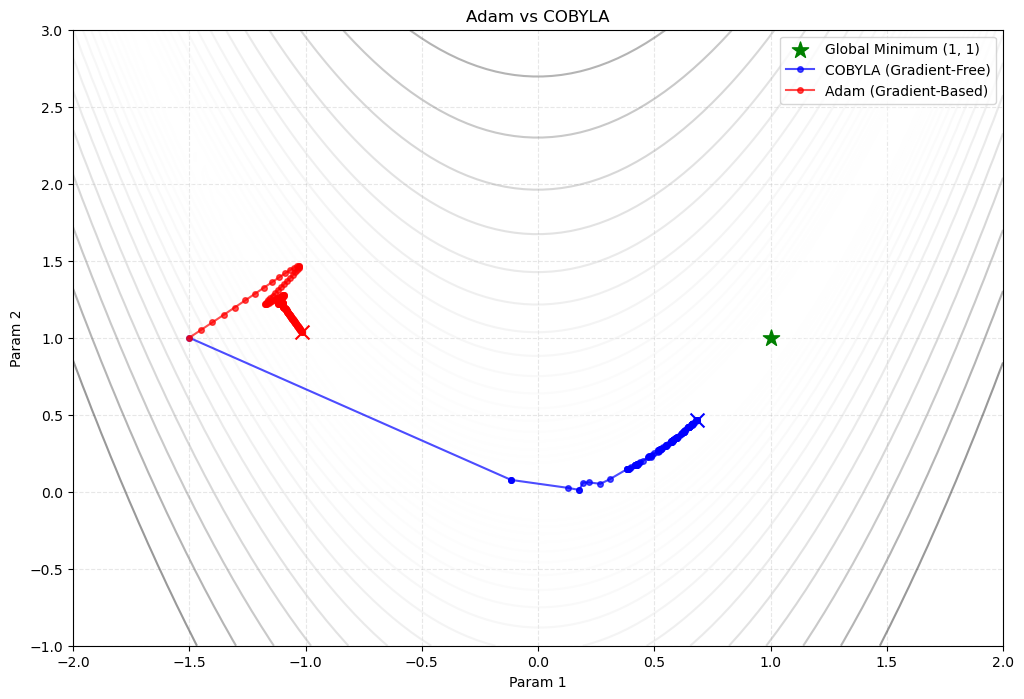

In [6]:
fig, ax = plt.subplots(figsize=(12, 8))

ax.contour(X, Y, Z, levels=np.logspace(-1, 3, 30), cmap='gray_r', alpha=0.4)
ax.scatter(1, 1, color='green', s=150, marker='*', label='Global Minimum (1, 1)', zorder=20)

ax.plot(cobyla_path[:, 0], cobyla_path[:, 1], 'o-', color='blue', label='COBYLA (Gradient-Free)', markersize=4, alpha=0.7)
ax.scatter(cobyla_path[-1, 0], cobyla_path[-1, 1], color='blue', s=100, marker='x', zorder=10)

ax.plot(adam_path[:, 0], adam_path[:, 1], 'o-', color='red', label='Adam (Gradient-Based)', markersize=4, alpha=0.7)
ax.scatter(adam_path[-1, 0], adam_path[-1, 1], color='red', s=100, marker='x', zorder=10)

ax.set_title("Adam vs COBYLA")
ax.set_xlabel("Param 1")
ax.set_ylabel("Param 2")
ax.legend()
ax.grid(True, linestyle='--', alpha=0.3)